In [1]:
from collections import deque

# Graph
graph = {
    'A': ['B', 'C'],
    'B': ['D', 'E'],
    'C': ['F'],
    'D': [],
    'E': [],
    'F': []
}

# BFS
def bfs(graph, start):
    visited = set()
    queue = deque([start])

    while queue:
        node = queue.popleft()
        if node not in visited:
            print(node, end=" ")
            visited.add(node)
            queue.extend(graph[node])

# DFS
def dfs(graph, node, visited=None):
    if visited is None:
        visited = set()

    if node not in visited:
        print(node, end=" ")
        visited.add(node)
        for neighbor in graph[node]:
            dfs(graph, neighbor, visited)

print("BFS:")
bfs(graph, 'A')

print("\nDFS:")
dfs(graph, 'A')

BFS:
A B C D E F 
DFS:
A B D E C F 

      Size  BFS Time  DFS Time
0     1000  0.000056  0.000017
1    40000  0.002262  0.000859
2    80000  0.004797  0.002190
3   200000  0.013009  0.005337
4  1000000  0.062645  0.023905


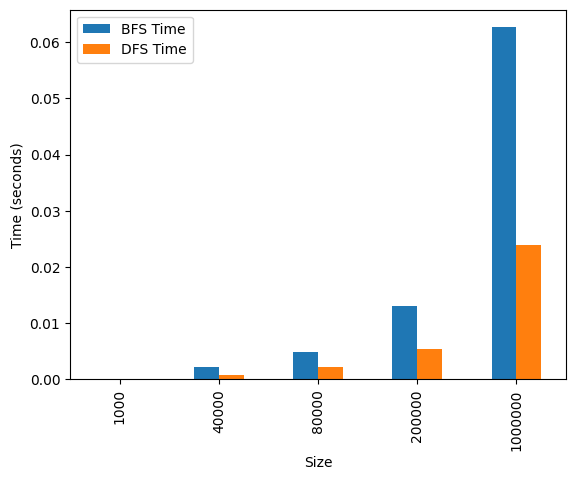

In [2]:
import random
import time
from collections import deque
import pandas as pd
import matplotlib.pyplot as plt

sizes = [1000, 40000, 80000, 200000, 1000000]

datasets = {}

# Generate unique random numbers
for size in sizes:
    datasets[size] = random.sample(range(size * 10), size)

# BFS Search
def bfs_search(data, goal):
    queue = deque(data)
    while queue:
        if queue.popleft() == goal:
            return True

# DFS Search
def dfs_search(data, goal):
    for item in data:
        if item == goal:
            return True

results = []

for size in sizes:
    data = datasets[size]
    goal = data[len(data) - 220]

    # BFS timing
    start = time.time()
    bfs_search(data, goal)
    bfs_time = time.time() - start

    # DFS timing
    start = time.time()
    dfs_search(data, goal)
    dfs_time = time.time() - start

    results.append((size, bfs_time, dfs_time))

# DataFrame
df = pd.DataFrame(results, columns=["Size", "BFS Time", "DFS Time"])
print(df)

# Plot
df.plot(x="Size", y=["BFS Time", "DFS Time"], kind="bar")
plt.ylabel("Time (seconds)")
plt.show()

In [4]:
from collections import deque

graph = {
    "Islamabad": ["Rawalpindi", "Lahore", "Peshawar"],
    "Rawalpindi": ["Islamabad", "Peshawar", "Quetta"],
    "Peshawar": ["Islamabad", "Rawalpindi", "Quetta"],
    "Lahore": ["Islamabad", "Multan", "Quetta"],
    "Multan": ["Lahore", "Karachi", "Quetta"],
    "Quetta": ["Rawalpindi", "Peshawar", "Multan", "Karachi"],
    "Karachi": ["Multan", "Quetta"]
}

def bfs_path(graph, start, goal):
    queue = deque([[start]])
    visited = set()

    while queue:
        path = queue.popleft()
        node = path[-1]

        if node == goal:
            return path

        if node not in visited:
            visited.add(node)
            for neighbor in graph[node]:
                new_path = list(path)
                new_path.append(neighbor)
                queue.append(new_path)

path = bfs_path(graph, "Islamabad", "Karachi")
print("Shortest Path:", path)

Shortest Path: ['Islamabad', 'Rawalpindi', 'Quetta', 'Karachi']


youtube link
https://youtu.be/lOP7s3iQp_0
